# **Plant Disease Classification**

**1. Mount Google Drive & Extract Dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

if not os.path.exists('/content/plantdoc/train_clean'):
    print("Extracting train.zip ...")
    with zipfile.ZipFile('/content/drive/MyDrive/PlantDoc/train.zip', 'r') as z:
        z.extractall('/content/plantdoc/train_clean')
    print("Done.")

if not os.path.exists('/content/plantdoc/val_clean'):
    print("Extracting val.zip ...")
    with zipfile.ZipFile('/content/drive/MyDrive/PlantDoc/val.zip', 'r') as z:
        z.extractall('/content/plantdoc/val_clean')
    print("Done.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2. Install Dependencies**

In [3]:
!pip install -q "albumentations>=2.0.8" torchmetrics wandb timm

**3. Imports, Token & Seed**

In [4]:
import os, random, math, json, io
from google.colab import userdata
from pathlib import Path
from collections import Counter
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import GradScaler, autocast

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import cv2

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import torchmetrics
import wandb

try:
    os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
    print("Hugging Face token loaded successfully:")
except:
    print("Warning: HF_TOKEN was not found in Secrets.")

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)


seed_everything(42)

Hugging Face token loaded successfully:


**4. Configuration**

In [5]:
class Config:
    TRAIN_DIR = Path("/content/plantdoc/train_clean/train")
    VAL_DIR   = Path("/content/plantdoc/val_clean/val")

    OUTPUT_DIR = Path("/content/drive/MyDrive/Plant_Disease_ML/outputs")

    BACKBONE = "efficientnet_b4"

    IMG_SIZE     = 380
    BATCH_SIZE = 32

    NUM_EPOCHS   = 50
    LR           = 3e-4
    WEIGHT_DECAY = 1e-4
    NUM_WORKERS  = 2
    PATIENCE     = 15
    USE_MIXUP    = False
    MIXUP_ALPHA  = 0.3
    LABEL_SMOOTHING = 0.1
    DROPOUT      = 0.2

    USE_WANDB     = True
    WANDB_PROJECT = "plant-disease-clf"

    SEED   = 42
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    AMP    = True


CFG = Config()
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {CFG.DEVICE}")

Device: cuda


**5. Disease Label Extraction, Transforms, Dataset & DataLoaders**

In [6]:
from pathlib import Path
from collections import defaultdict

def build_disease_mapping_prefix(root_dirs: list, verbose: bool = True) -> dict[str, str]:
    all_folders = set()
    for root in root_dirs:
        root = Path(root)
        if root.exists():
            for f in root.iterdir():
                if f.is_dir() and not f.name.startswith("__"):
                    all_folders.add(f.name.lower().strip())

    groups = defaultdict(list)
    for folder in all_folders:
        groups[folder.split()[0]].append(folder.split())

    folder_to_disease = {}
    for folder in all_folders:
        words = folder.split()
        first_word = words[0]
        group = groups[first_word]

        if len(group) > 1:
            plant_len = 0
            for col in zip(*group):
                if len(set(col)) == 1:
                    plant_len += 1
                else:
                    break
        else:
            plant_len = 1

        disease = " ".join(words[plant_len:]).strip()
        folder_to_disease[folder] = disease if disease else "healthy"

    if verbose:
        disease_to_folders = defaultdict(list)
        for folder, disease in folder_to_disease.items():
            disease_to_folders[disease].append(folder)

        print(f"\n{'='*60}")
        print(f"Detected {len(set(folder_to_disease.values()))} unique diseases (Prefix Heuristic)")

        cross = {d: fs for d, fs in disease_to_folders.items() if len(fs) >= 2}
        print(f"\n✅ Cross-plant diseases ({len(cross)}):")
        for d, fs in sorted(cross.items()):
            print(f"  '{d}': {fs}")

        singles = {d: fs for d, fs in disease_to_folders.items() if len(fs) == 1}
        print(f"\n⚠️  Single-plant diseases ({len(singles)}):")
        for d, fs in sorted(singles.items()):
            print(f"  '{d}': {fs[0]}")

    return folder_to_disease

FOLDER_TO_DISEASE = build_disease_mapping_prefix([CFG.TRAIN_DIR, CFG.VAL_DIR])

def extract_disease(folder_name: str) -> str:
    return FOLDER_TO_DISEASE.get(folder_name.strip().lower(), "")

_all_diseases = set(FOLDER_TO_DISEASE.values()) - {""}
DISEASE2IDX: dict[str, int] = {d: i for i, d in enumerate(sorted(_all_diseases))}
IDX2DISEASE: dict[int, str] = {v: k for k, v in DISEASE2IDX.items()}
NUM_CLASSES = len(DISEASE2IDX)

print(f"\nUnique diseases configured for training: {NUM_CLASSES}")
print("\nTest 'bell pepper blossom end rot':", extract_disease("bell pepper blossom end rot"))

def get_train_transforms(img_size: int) -> A.Compose:
    return A.Compose([
        A.RandomResizedCrop(size=(img_size, img_size), scale=(0.8, 1.0)),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomRotate90(p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02, p=0.5),
        A.CoarseDropout(
            num_holes_range=(1, 4),
            hole_height_range=(8, img_size // 10),
            hole_width_range=(8, img_size // 10),
            p=0.3
        ),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


def get_val_transforms(img_size: int) -> A.Compose:
    new_size = int(img_size * 1.14)
    return A.Compose([
        A.Resize(height=new_size, width=new_size),
        A.CenterCrop(height=img_size, width=img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

class PlantDiseaseDataset(Dataset):
    def __init__(self, root: Path, transform: A.Compose):
        self.transform = transform
        self.samples: list[tuple[Path, int]] = []

        for folder in sorted(root.iterdir()):
            if not folder.is_dir() or folder.name.startswith("__"):
                continue
            disease = extract_disease(folder.name)
            if not disease or disease not in DISEASE2IDX:
                continue
            label = DISEASE2IDX[disease]
            for img_path in list(folder.glob("*.jpg")) + list(folder.glob("*.png")):
                self.samples.append((img_path, label))

        print(f"  {root.name}: {len(self.samples)} images across {NUM_CLASSES} disease classes")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        path, label = self.samples[idx]
        img = cv2.imread(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = self.transform(image=img)["image"]
        return augmented, label


def make_weighted_sampler(dataset: PlantDiseaseDataset) -> WeightedRandomSampler:
    counts = Counter(label for _, label in dataset.samples)
    sample_weights = [1.0 / counts[label] for _, label in dataset.samples]
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )

train_ds = PlantDiseaseDataset(CFG.TRAIN_DIR, get_train_transforms(CFG.IMG_SIZE))
val_ds   = PlantDiseaseDataset(CFG.VAL_DIR,   get_val_transforms(CFG.IMG_SIZE))

sampler = make_weighted_sampler(train_ds)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG.BATCH_SIZE,
    sampler=sampler,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=CFG.BATCH_SIZE * 2,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
)


Detected 39 unique diseases (Prefix Heuristic)

✅ Cross-plant diseases (16):
  'alternaria leaf spot': ['cabbage alternaria leaf spot', 'broccoli alternaria leaf spot', 'cauliflower alternaria leaf spot']
  'anthracnose': ['peach anthracnose', 'celery anthracnose', 'strawberry anthracnose', 'blueberry anthracnose', 'banana anthracnose']
  'bacterial wilt': ['cucumber bacterial wilt', 'zucchini bacterial wilt']
  'black rot': ['apple black rot', 'grape black rot', 'cabbage black rot', 'coffee black rot']
  'brown rot': ['peach brown rot', 'plum brown rot']
  'brown spot': ['soybean brown spot', 'tobacco brown spot']
  'downy mildew': ['cabbage downy mildew', 'grape downy mildew', 'basil downy mildew', 'broccoli downy mildew', 'lettuce downy mildew', 'zucchini downy mildew', 'soybean downy mildew']
  'early blight': ['tomato early blight', 'celery early blight', 'potato early blight']
  'late blight': ['potato late blight', 'tomato late blight']
  'leaf rust': ['wheat leaf rust', 'coffe

**6. Debug — Test Label Extraction**

In [7]:
print(extract_disease("bell pepper blossom end rot"))

blossom end rot


 **7. Model Architecture**

In [8]:
class DiseaseClassifier(nn.Module):
    def __init__(self, backbone: str, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.backbone = timm.create_model(
            backbone,
            pretrained=True,
            num_classes=0,
            global_pool="avg",
        )
        feat_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(feat_dim, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.backbone(x)
        return self.head(feats)


def build_model(cfg: Config) -> DiseaseClassifier:
    model = DiseaseClassifier(cfg.BACKBONE, NUM_CLASSES, cfg.DROPOUT).to(cfg.DEVICE)
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nBackbone         : {cfg.BACKBONE}")
    print(f"Total params     : {total:,}")
    print(f"Trainable params : {trainable:,}")
    return model

def freeze_backbone(model):
    for param in model.backbone.parameters():
        param.requires_grad = False

def unfreeze_backbone(model):
    for param in model.backbone.parameters():
        param.requires_grad = True

model = build_model(CFG)

freeze_backbone(model)
trainable_after_freeze = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable after freeze : {trainable_after_freeze:,} (should be very small — head only)")


Backbone         : efficientnet_b4
Total params     : 17,618,543
Trainable params : 17,618,543
Trainable after freeze : 69,927 (should be very small — head only)


**8. Loss, Optimizer & Scheduler**

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=CFG.LABEL_SMOOTHING)

def get_optimizer(model, cfg, unfrozen=False):
    if not unfrozen:
        return torch.optim.AdamW(
            model.head.parameters(),
            lr=cfg.LR,
            weight_decay=cfg.WEIGHT_DECAY,
        )
    else:
        return torch.optim.AdamW([
            {"params": model.backbone.parameters(), "lr": cfg.LR * 0.05},
            {"params": model.head.parameters(),     "lr": cfg.LR * 0.5},
        ], weight_decay=cfg.WEIGHT_DECAY)

optimizer = get_optimizer(model, CFG, unfrozen=False)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=5,
    eta_min=1e-6
)

scaler = GradScaler("cuda", enabled=CFG.AMP)

**9. Mixup Augmentation**

In [10]:
def mixup_data(x: torch.Tensor, y: torch.Tensor, alpha: float = 0.4):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam


def mixup_criterion(pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

**10. Metrics**

In [11]:
map_metric = torchmetrics.AveragePrecision(
    task="multiclass", num_classes=NUM_CLASSES, average="macro"
).to(CFG.DEVICE)

acc_metric = torchmetrics.Accuracy(
    task="multiclass", num_classes=NUM_CLASSES
).to(CFG.DEVICE)

**11. Training Loop — train_one_epoch**

In [12]:
def train_one_epoch(model, loader, optimizer, scheduler, scaler, epoch: int):
    model.train()
    total_loss = 0.0
    acc_metric.reset()

    for step, (imgs, labels) in enumerate(loader):
        imgs   = imgs.to(CFG.DEVICE, non_blocking=True)
        labels = labels.to(CFG.DEVICE, non_blocking=True)

        if CFG.USE_MIXUP:
            imgs, labels_a, labels_b, lam = mixup_data(imgs, labels, CFG.MIXUP_ALPHA)

        with autocast("cuda", enabled=CFG.AMP):
            logits = model(imgs)
            loss = (
                mixup_criterion(logits, labels_a, labels_b, lam)
                if CFG.USE_MIXUP
                else criterion(logits, labels)
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

        #scheduler.step(epoch - 1 + step / len(loader))

        total_loss += loss.item()
        acc_metric.update(logits.argmax(1), labels_a if CFG.USE_MIXUP else labels)

        if step % 50 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch} | step {step}/{len(loader)} | loss={loss.item():.4f} | lr={lr_now:.2e}")

    return total_loss / len(loader), acc_metric.compute().item()


@torch.no_grad()
def validate(model, loader, epoch: int):
    model.eval()
    total_loss = 0.0
    acc_metric.reset()
    map_metric.reset()
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs   = imgs.to(CFG.DEVICE, non_blocking=True)
        labels = labels.to(CFG.DEVICE, non_blocking=True)

        with autocast("cuda", enabled=CFG.AMP):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        total_loss += loss.item()
        probs = logits.softmax(1)
        acc_metric.update(probs.argmax(1), labels)
        map_metric.update(probs, labels)
        all_preds.extend(probs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return (
        total_loss / len(loader),
        acc_metric.compute().item(),
        map_metric.compute().item(),
        np.array(all_preds),
        np.array(all_labels),
    )

def plot_confusion_matrix(labels, preds, class_names, save_path):
    cm = confusion_matrix(labels, preds)
    size = max(10, NUM_CLASSES)
    fig, ax = plt.subplots(figsize=(size, size - 2))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Confusion Matrix — Disease Classification")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Confusion matrix saved -> {save_path}")

**12. Main Training Function**

In [ ]:
def train(cfg: Config):
    global optimizer, scheduler

    if cfg.USE_WANDB:
        wandb.init(
            project=cfg.WANDB_PROJECT,
            config={
                "backbone":        cfg.BACKBONE,
                "img_size":        cfg.IMG_SIZE,
                "batch_size":      cfg.BATCH_SIZE,
                "lr":              cfg.LR,
                "epochs":          cfg.NUM_EPOCHS,
                "label_smoothing": cfg.LABEL_SMOOTHING,
                "mixup":           cfg.USE_MIXUP,
                "num_classes":     NUM_CLASSES,
            },
        )

    best_map   = 0.0
    no_improve = 0
    best_ckpt  = cfg.OUTPUT_DIR / "best_model.pth"

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        if epoch == 1:
            freeze_backbone(model)
            print("Backbone frozen — training head only")

        if epoch == 4:
            unfreeze_backbone(model)
            optimizer = get_optimizer(model, cfg, unfrozen=True)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=cfg.NUM_EPOCHS - 3, eta_min=1e-6
            )
            print("Backbone unfrozen early — total optimization started.")

        print(f"\n{'='*60}")
        print(f"EPOCH {epoch}/{cfg.NUM_EPOCHS}")

        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, scheduler, scaler, epoch
        )
        val_loss, val_acc, val_map, preds, labels = validate(model, val_loader, epoch)

        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']

        print(
            f"  TRAIN  loss={tr_loss:.4f}  acc={tr_acc:.4f}\n"
            f"  VAL    loss={val_loss:.4f}  acc={val_acc:.4f}  mAP={val_map:.4f}"
        )

        if cfg.USE_WANDB:
            wandb.log({
                "epoch":      epoch,
                "train/loss": tr_loss,
                "train/acc":  tr_acc,
                "val/loss":   val_loss,
                "val/acc":    val_acc,
                "val/mAP":    val_map,
                "lr":         current_lr,
            })

        if val_map > best_map:
            best_map   = val_map
            no_improve = 0
            torch.save({
                "epoch":       epoch,
                "model_state": model.state_dict(),
                "val_acc":     val_acc,
                "val_map":     val_map,
                "disease2idx": DISEASE2IDX,
                "backbone":    cfg.BACKBONE,
            }, best_ckpt)
            print(f"  [SAVED] New best mAP={best_map:.4f}")
        else:
            no_improve += 1
            if no_improve >= cfg.PATIENCE:
                print(f"  [EARLY STOP] No improvement for {cfg.PATIENCE} epochs.")
                break

    print(f"\nTraining complete. Best val mAP: {best_map:.4f}")

    print("Loading best checkpoint for confusion matrix...")
    ckpt = torch.load(best_ckpt, map_location=cfg.DEVICE)
    model.load_state_dict(ckpt["model_state"])
    _, _, _, preds, labels = validate(model, val_loader, epoch=-1)

    class_names = [IDX2DISEASE[i] for i in range(NUM_CLASSES)]
    plot_confusion_matrix(labels, preds, class_names, cfg.OUTPUT_DIR / "confusion_matrix.png")

    if cfg.USE_WANDB:
        wandb.finish()

    return best_ckpt


best_ckpt_path = train(CFG)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mansuryansona04 (mansuryansona04-npua) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Backbone frozen — training head only

EPOCH 1/50
  Epoch 1 | step 0/243 | loss=3.6608 | lr=3.00e-04
  Epoch 1 | step 50/243 | loss=3.5401 | lr=3.00e-04
  Epoch 1 | step 100/243 | loss=3.4375 | lr=3.00e-04
  Epoch 1 | step 150/243 | loss=3.3867 | lr=3.00e-04
  Epoch 1 | step 200/243 | loss=3.2040 | lr=3.00e-04
  TRAIN  loss=3.3980  acc=0.3857
  VAL    loss=3.1691  acc=0.4667  mAP=0.4723
  [SAVED] New best mAP=0.4723

EPOCH 2/50
  Epoch 2 | step 0/243 | loss=3.2307 | lr=2.71e-04
  Epoch 2 | step 50/243 | loss=3.1132 | lr=2.71e-04
  Epoch 2 | step 100/243 | loss=3.0780 | lr=2.71e-04
  Epoch 2 | step 150/243 | loss=2.9421 | lr=2.71e-04
  Epoch 2 | step 200/243 | loss=2.7999 | lr=2.71e-04
  TRAIN  loss=2.9796  acc=0.5271
  VAL    loss=2.8405  acc=0.4897  mAP=0.5171
  [SAVED] New best mAP=0.5171

EPOCH 3/50
  Epoch 3 | step 0/243 | loss=2.9725 | lr=1.97e-04
  Epoch 3 | step 50/243 | loss=2.9081 | lr=1.97e-04
  Epoch 3 | step 100/243 | loss=2.5975 | lr=1.97e-04
  Epoch 3 | step 150/243 | loss

**13. Resume Training from Checkpoint**

In [13]:
import torch

CHECKPOINT_PATH = Path("/content/drive/MyDrive/Plant_Disease_ML/outputs/best_model.pth")

if CHECKPOINT_PATH.exists():
    print(f"==> Loading checkpoint from Drive: {CHECKPOINT_PATH}")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=CFG.DEVICE)

    model = build_model(CFG)
    model.load_state_dict(ckpt["model_state"])

    start_epoch = ckpt["epoch"] + 1
    best_map = ckpt.get("val_map", 0.0)

    unfreeze_backbone(model)
    optimizer = get_optimizer(model, CFG, unfrozen=True)

    remaining_epochs = CFG.NUM_EPOCHS - start_epoch + 1
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=remaining_epochs, eta_min=1e-6
    )

    print(f"==> Ready! Resuming from Epoch {start_epoch}")
    print(f"==> Current Best Validation mAP: {best_map:.4f}")

    if CFG.USE_WANDB:
        wandb.init(project=CFG.WANDB_PROJECT, name=f"resume_from_ep{start_epoch}", resume="allow")

    for epoch in range(start_epoch, CFG.NUM_EPOCHS + 1):
        print(f"\n{'='*60}")
        print(f"RESUME EPOCH {epoch}/{CFG.NUM_EPOCHS}")

        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, scheduler, scaler, epoch)

        val_loss, val_acc, val_map, preds, labels = validate(model, val_loader, epoch)

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        print(
            f"  TRAIN  loss={tr_loss:.4f}  acc={tr_acc:.4f}\n"
            f"  VAL    loss={val_loss:.4f}  acc={val_acc:.4f}  mAP={val_map:.4f}"
        )

        if CFG.USE_WANDB:
            wandb.log({
                "epoch": epoch, "train/loss": tr_loss, "train/acc": tr_acc,
                "val/loss": val_loss, "val/acc": val_acc, "val/mAP": val_map,
                "lr": current_lr
            })

        if val_map > best_map:
            best_map = val_map
            torch.save({
                "epoch": epoch, "model_state": model.state_dict(),
                "val_acc": val_acc, "val_map": val_map,
                "disease2idx": DISEASE2IDX, "backbone": CFG.BACKBONE,
            }, CHECKPOINT_PATH)
            print(f"  [SAVED] New best mAP={best_map:.4f} to Drive")

    print(f"\nResumed training complete. Final best val mAP: {best_map:.4f}")
else:
    print("Error: Checkpoint file not found on Drive.")

==> Loading checkpoint from Drive: /content/drive/MyDrive/Plant_Disease_ML/outputs/best_model.pth

Backbone         : efficientnet_b4
Total params     : 17,618,543
Trainable params : 17,618,543
==> Ready! Resuming from Epoch 29
==> Current Best Validation mAP: 0.8657


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: mansuryansona04 (mansuryansona04-npua) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



RESUME EPOCH 29/50
  Epoch 29 | step 0/243 | loss=1.2733 | lr=1.50e-05
  Epoch 29 | step 50/243 | loss=0.9179 | lr=1.50e-05
  Epoch 29 | step 100/243 | loss=1.1236 | lr=1.50e-05
  Epoch 29 | step 150/243 | loss=1.3291 | lr=1.50e-05
  Epoch 29 | step 200/243 | loss=1.0074 | lr=1.50e-05
  TRAIN  loss=1.0786  acc=0.9023
  VAL    loss=1.2663  acc=0.7949  mAP=0.8660
  [SAVED] New best mAP=0.8660 to Drive

RESUME EPOCH 30/50
  Epoch 30 | step 0/243 | loss=1.0901 | lr=1.49e-05
  Epoch 30 | step 50/243 | loss=1.0013 | lr=1.49e-05
  Epoch 30 | step 100/243 | loss=1.1628 | lr=1.49e-05
  Epoch 30 | step 150/243 | loss=1.1034 | lr=1.49e-05
  Epoch 30 | step 200/243 | loss=0.9699 | lr=1.49e-05
  TRAIN  loss=1.0802  acc=0.9038
  VAL    loss=1.2408  acc=0.7949  mAP=0.8693
  [SAVED] New best mAP=0.8693 to Drive

RESUME EPOCH 31/50
  Epoch 31 | step 0/243 | loss=1.2163 | lr=1.47e-05
  Epoch 31 | step 50/243 | loss=1.0830 | lr=1.47e-05
  Epoch 31 | step 100/243 | loss=1.0872 | lr=1.47e-05
  Epoch 31 | 

**14. Inference Class — DiseasePredictor (Single & TTA)**

In [14]:
class DiseasePredictor:
    def __init__(self, ckpt_path: str, device: Optional[torch.device] = None):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        ckpt = torch.load(ckpt_path, map_location=self.device)
        d2i: dict[str, int] = ckpt["disease2idx"]
        self.idx2disease = {v: k for k, v in d2i.items()}
        num_classes = len(d2i)

        self.model = DiseaseClassifier(ckpt["backbone"], num_classes, dropout=0.0)
        self.model.load_state_dict(ckpt["model_state"])
        self.model.to(self.device).eval()

        self.transform = get_val_transforms(CFG.IMG_SIZE)

    @torch.no_grad()
    def predict(self, image_path: str) -> dict:
        img = cv2.imread(image_path)
        if img is None:
            raise FileNotFoundError(f"Cannot read image: {image_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        tensor = self.transform(image=img)["image"].unsqueeze(0).to(self.device)

        with autocast("cuda", enabled=CFG.AMP):
            logits = self.model(tensor)
        probs = logits.softmax(1).squeeze().cpu().float().numpy()

        top3_idx = probs.argsort()[::-1][:3]
        top3 = [
            {"disease": self.idx2disease[int(i)], "confidence": float(probs[i])}
            for i in top3_idx
        ]
        return {
            "disease":    top3[0]["disease"],
            "confidence": top3[0]["confidence"],
            "top3":       top3,
        }

    @torch.no_grad()
    def tta_predict(self, image_path: str) -> dict:
        img = cv2.imread(image_path)
        if img is None:
            raise FileNotFoundError(f"Cannot read image: {image_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        variants = [
            self.transform(image=img)["image"],
            self.transform(image=cv2.flip(img, 1))["image"], # horizontal flip
            self.transform(image=cv2.flip(img, 0))["image"], # vertical flip
            self.transform(image=cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE))["image"],
            self.transform(image=cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE))["image"],
        ]

        batch = torch.stack(variants).to(self.device)
        with autocast("cuda", enabled=CFG.AMP):
            logits = self.model(batch)

        probs = logits.softmax(1).mean(0).cpu().float().numpy()

        top3_idx = probs.argsort()[::-1][:3]
        top3 = [
            {"disease": self.idx2disease[int(i)], "confidence": float(probs[i])}
            for i in top3_idx
        ]
        return {
            "disease":    top3[0]["disease"],
            "confidence": top3[0]["confidence"],
            "top3":       top3,
        }

**15. Export FastAPI Server Code**

In [15]:
_FASTAPI_CODE = '''
from fastapi import FastAPI, UploadFile, File, HTTPException
from fastapi.responses import JSONResponse
import tempfile, os, torch

from plant_disease_classifier import DiseasePredictor, CFG

app = FastAPI(title="Plant Disease Classifier", version="1.0")

_predictor: DiseasePredictor | None = None


@app.on_event("startup")
def load_model():
    global _predictor
    ckpt = str(CFG.OUTPUT_DIR / "best_model.pth")
    _predictor = DiseasePredictor(ckpt)
    print("Model loaded and ready.")


@app.post("/predict")
async def predict_disease(file: UploadFile = File(...)):
    if not file.content_type.startswith("image/"):
        raise HTTPException(status_code=400, detail="Uploaded file must be an image.")

    suffix = os.path.splitext(file.filename)[-1] or ".jpg"
    with tempfile.NamedTemporaryFile(delete=False, suffix=suffix) as tmp:
        tmp.write(await file.read())
        tmp_path = tmp.name

    try:
        result = _predictor.predict(tmp_path)
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))
    finally:
        os.unlink(tmp_path)

    return JSONResponse(content={
        "disease":    result["disease"],
        "confidence": round(result["confidence"], 4),
    })


@app.get("/health")
def health():
    return {"status": "ok", "model_loaded": _predictor is not None}
'''

_api_path = CFG.OUTPUT_DIR / "api.py"
_api_path.write_text(_FASTAPI_CODE.strip())
print(f"FastAPI server written to {_api_path}")
print("Run with:  uvicorn api:app --host 0.0.0.0 --port 8000")

FastAPI server written to /content/drive/MyDrive/Plant_Disease_ML/outputs/api.py
Run with:  uvicorn api:app --host 0.0.0.0 --port 8000


**16. Backbone Ablation Summary**

In [25]:
def ablation_summary():
    candidates = [
        "efficientnet_b0",
        "efficientnet_b2",
        "efficientnet_b4",
        "mobilenetv3_large_100",
        "resnet50",
        "convnext_tiny",
    ]
    print(f"\n{'Backbone Architecture':<25} | {'Params (M)':>12} | {'Feature Dim':>12} | {'Status'}")
    print("-" * 75)
    for name in candidates:
        try:
            m = timm.create_model(name, pretrained=False, num_classes=0, global_pool="avg")
            p = sum(x.numel() for x in m.parameters()) / 1e6
            f = m.num_features
            status = "SELECTED" if name == "efficientnet_b4" else "Candidate"
            print(f"{name:<25} | {p:>10.2f}M | {f:>12} | {status}")
        except Exception as e:
            print(f"{name:<25} | ERROR: {e}")

ablation_summary()

import random
val_images = list(CFG.VAL_DIR.rglob("*.jpg")) + list(CFG.VAL_DIR.rglob("*.png"))
test_img = str(random.choice(val_images))

final_model_path = "/content/drive/MyDrive/Plant_Disease_ML/outputs/best_model.pth"
predictor = DiseasePredictor(str(final_model_path))
result = predictor.tta_predict(test_img)

print(f"\n{'='*50}")
print(f"TEST IMAGE PREDICTION (TTA ENABLED)")
print(f"{'='*50}")
print(f"File: {Path(test_img).name}")
print(f"Result: {result['disease'].upper()}")
print(f"Confidence: {result['confidence']:.2%}")
print(f"\nTOP 3 PREDICTIONS:")

for i, top in enumerate(result['top3'], 1):
    print(f"  {i}. {top['disease']:<25} -> {top['confidence']:.2%}")


Backbone Architecture     |   Params (M) |  Feature Dim | Status
---------------------------------------------------------------------------
efficientnet_b0           |       4.01M |         1280 | Candidate
efficientnet_b2           |       7.70M |         1408 | Candidate
efficientnet_b4           |      17.55M |         1792 | SELECTED
mobilenetv3_large_100     |       4.20M |          960 | Candidate
resnet50                  |      23.51M |         2048 | Candidate
convnext_tiny             |      27.82M |          768 | Candidate

TEST IMAGE PREDICTION (TTA ENABLED)
File: coffee_berry_blotch_Google_0010.jpg
Result: BERRY BLOTCH
Confidence: 83.69%

TOP 3 PREDICTIONS:
  1. berry blotch              -> 83.69%
  2. black rot                 -> 2.97%
  3. scab                      -> 2.11%


**17. Prediction Demo & Batch Visualization**

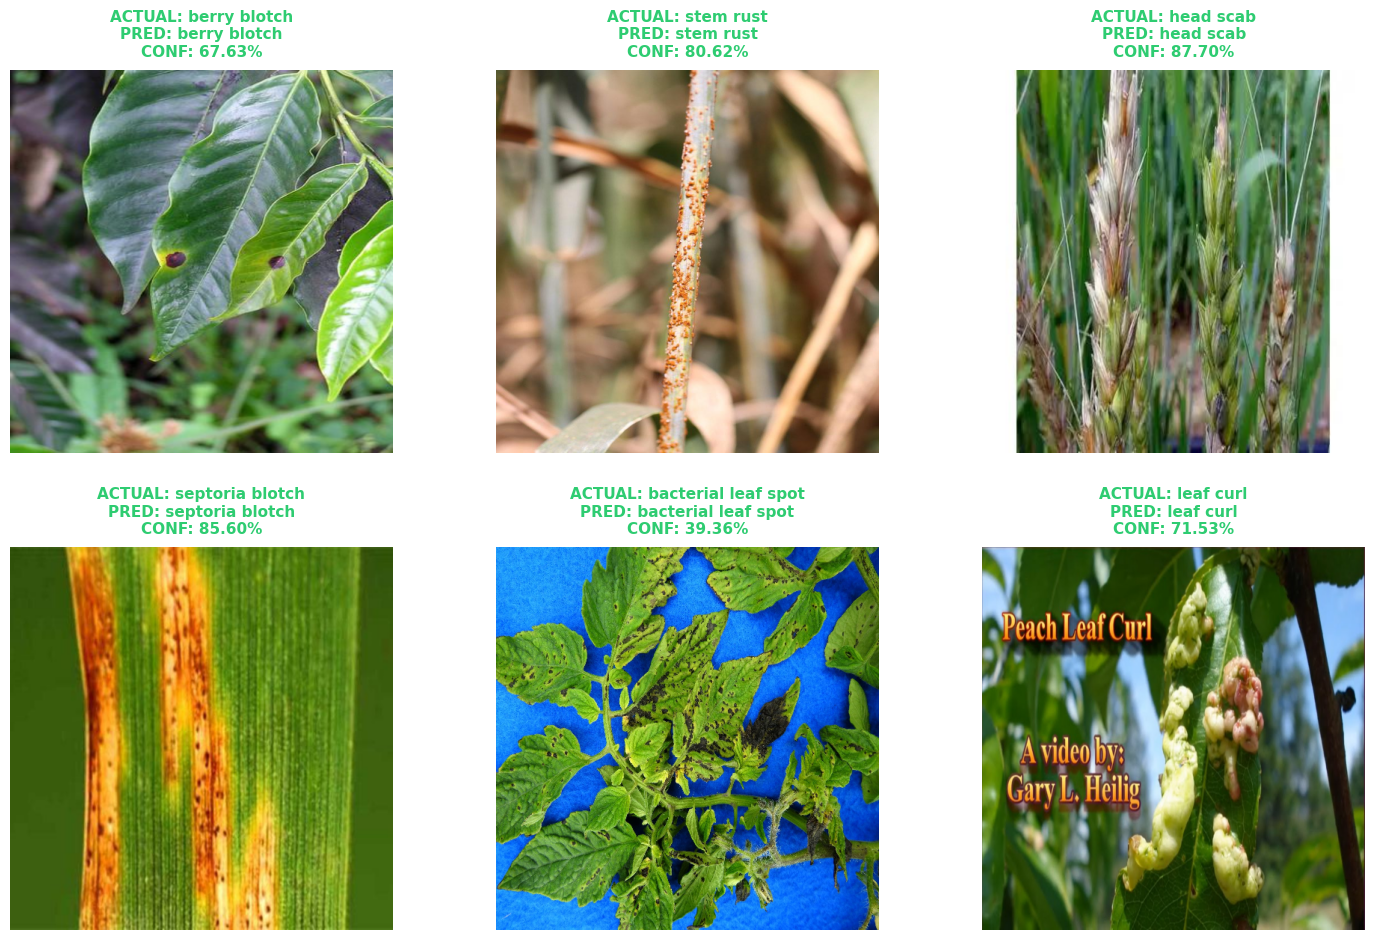

✅ Clean visualization saved to: /content/drive/MyDrive/Plant_Disease_ML/outputs/visuals/prediction_samples_clean.png


In [26]:
import matplotlib.pyplot as plt
import cv2

def visualize_predictions(predictor, val_ds, n_images=6):
    save_dir = "/content/drive/MyDrive/Plant_Disease_ML/outputs/visuals"
    os.makedirs(save_dir, exist_ok=True)

    plt.figure(figsize=(15, 10))

    indices = random.sample(range(len(val_ds.samples)), n_images)

    for i, idx in enumerate(indices):
        img_path, label_idx = val_ds.samples[idx]
        true_disease = IDX2DISEASE[label_idx]

        result = predictor.tta_predict(str(img_path))
        pred_disease = result['disease']
        conf = result['confidence']

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (512, 512))

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)

        color = '#2ecc71' if pred_disease == true_disease else '#e74c3c'

        title = f"ACTUAL: {true_disease}\nPRED: {pred_disease}\nCONF: {conf:.2%}"
        plt.title(title, color=color, fontsize=11, fontweight='bold', pad=10)

        plt.axis('off')

    plt.tight_layout(pad=3.0)

    plt.savefig(f"{save_dir}/prediction_samples_clean.png", dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Clean visualization saved to: {save_dir}/prediction_samples_clean.png")

visualize_predictions(predictor, val_ds)